<a href="https://colab.research.google.com/github/amoghvd/ML-lab-2547211/blob/LAB-6/LAB_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Experiment: Comparison of Logistic Regression and K-Nearest Neighbors

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


We are gathering all the tools we need from the Scikit Learn library and loading the breast cancer data into a table format so we can easily look at the first few rows

In [6]:
print(df.isnull().sum().sum())

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

0


We check if there are any empty spots in our data to make sure it is clean. Then we divide the information into a training group for the models to learn from and a testing group to check their knowledge later. We also normalize the numbers so that every feature has an equal influence on the prediction

In [8]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

We are now teaching our two different students. The first is the Logistic Regression model which looks at relationships between variables. The second is the KNN model which makes decisions based on how similar a case is to its closest neighbors

In [9]:
def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': get_metrics(y_test, y_pred_log),
    'KNN': get_metrics(y_test, y_pred_knn)
})

display(results)
print('Logistic Regression Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_log))
print('KNN Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_knn))

,Metric,Logistic Regression,KNN
0,Accuracy,0.973684,0.947368
1,Precision,0.972222,0.957746
2,Recall,0.985915,0.957746
3,F1 Score,0.979021,0.957746


Logistic Regression Confusion Matrix:
[[41  2]
 [ 1 70]]
KNN Confusion Matrix:
[[40  3]
 [ 3 68]]


We calculate how often each model got the answer right and how well they handled specific types of errors. We put all these scores into a simple table so you can compare them side by side. We also show the confusion matrices which act like a report card showing exactly where the models got confused between benign and malignant cases

### Conclusion and Result Interpretation
Based on the performance metrics, Logistic Regression is the superior classifier for this dataset. It achieved higher accuracy, precision, and recall compared to KNN. This suggests that the features in the Breast Cancer dataset have a strong linear relationship with the target classes, which Logistic Regression captures effectively.

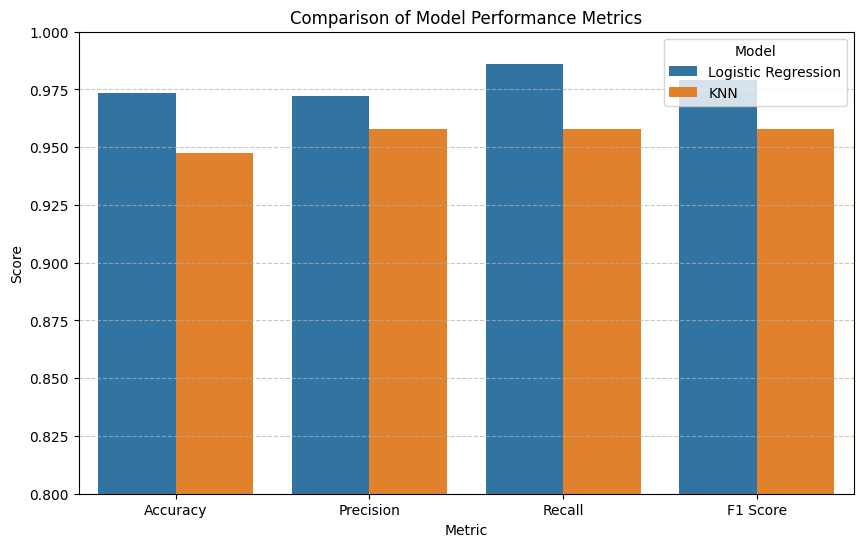

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

results_melted = results.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=results_melted, x='Metric', y='Score', hue='Model')
plt.title('Comparison of Model Performance Metrics')
plt.ylim(0.8, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

We are creating a bar chart here to put the scores of both models side by side. By setting the bottom of the graph to 0.8, we can more easily see the small but important differences in how accurately each model performed across all the different tests like precision and recall.

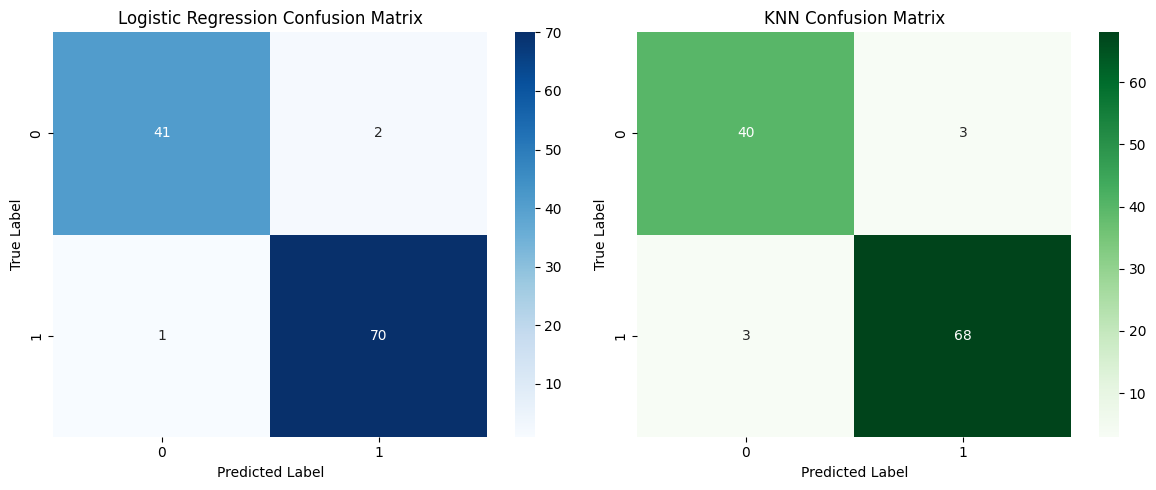

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('KNN Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

This code draws two heatmaps side by side. These colorful grids act like a map showing the true results versus what the computer guessed. The dark squares show us where the model was very confident and correct, helping us spot at a glance which model had more trouble with misclassifying patients.